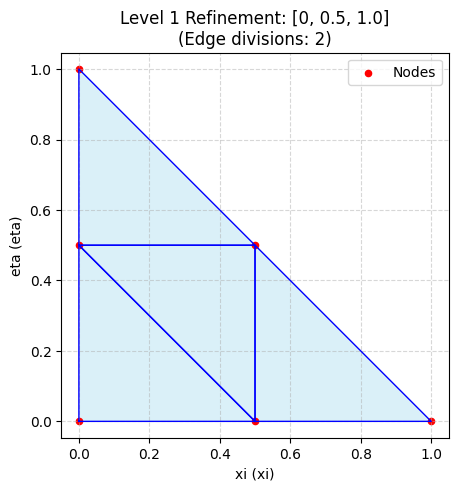

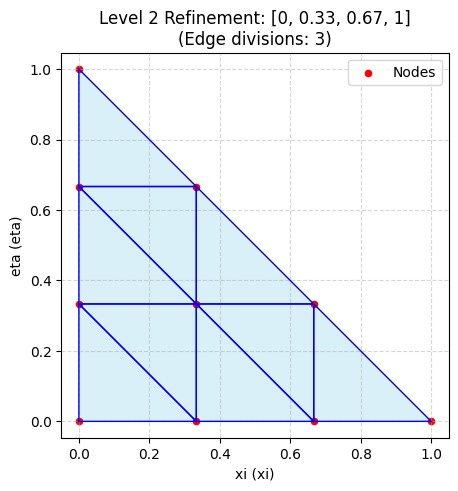

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def generate_subdivided_triangle(n_div):
    """
    將頂點為 (0,0), (1,0), (0,1) 的參考三角形切分成 n_div^2 個小三角形。
    """
    nodes = []
    # 根據筆記中的 [0, 0.25, 0.5...] 生成節點座標
    for j in range(n_div + 1):
        for i in range(n_div + 1 - j):
            x = i / n_div
            y = j / n_div
            nodes.append((x, y))
    nodes = np.array(nodes)

    # 建立三角形的連接性 (Connectivity)
    triangles = []
    node_idx = {}
    curr = 0
    for j in range(n_div + 1):
        for i in range(n_div + 1 - j):
            node_idx[(i, j)] = curr
            curr += 1
            
    for j in range(n_div):
        for i in range(n_div - j):
            # 正向三角形
            triangles.append([node_idx[(i, j)], node_idx[(i+1, j)], node_idx[(i, j+1)]])
            # 反向三角形 (填補間隙)
            if i + j + 1 < n_div:
                triangles.append([node_idx[(i+1, j)], node_idx[(i+1, j+1)], node_idx[(i, j+1)]])
                
    return nodes, triangles

def plot_mesh(n_div, title):
    nodes, triangles = generate_subdivided_triangle(n_div)
    plt.figure(figsize=(5, 5))
    for tri in triangles:
        t_nodes = nodes[tri]
        t_plot = np.vstack([t_nodes, t_nodes[0]]) # 閉合三角形
        plt.plot(t_plot[:, 0], t_plot[:, 1], 'b-', linewidth=1)
        plt.fill(t_plot[:, 0], t_plot[:, 1], 'skyblue', alpha=0.3)
    
    plt.scatter(nodes[:, 0], nodes[:, 1], c='red', s=20, label='Nodes')
    plt.title(f"{title}\n(Edge divisions: {n_div})")
    plt.xlabel("xi (xi)")
    plt.ylabel("eta (eta)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal')
    plt.legend()
    plt.show()

# 執行繪圖
plot_mesh(2, "Level 1 Refinement: [0, 0.5, 1.0]")
plot_mesh(3, "Level 2 Refinement: [0, 0.33, 0.67, 1]")

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.core.generators import build_nodes
from src.core.render_utils import VERTICES_2D, VERTICES_3D
from src.bases import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
from src.reconstruction import build_differentiation_matrices


def get_reference_data(method: str, k: int):
    nodes = build_nodes(method, k, VERTICES_2D, VERTICES_3D)
    bary_coords = np.array([n.barycentric for n in nodes], dtype=float)
    weights = np.array([n.weight for n in nodes], dtype=float)
    xi = 2.0 * bary_coords[:, 2] - 1.0
    eta = 2.0 * bary_coords[:, 1] - 1.0
    return {
        "nodes": nodes,
        "bary_coords": bary_coords,
        "weights": weights,
        "xi": xi,
        "eta": eta,
    }


def exponent_pairs(total_degree: int):
    return [(i, total_degree - i) for i in range(total_degree + 1)]

def compute_geometric_factors(v1, v2, v3):
    """
    根據給定的三個頂點座標，計算直邊三角形的 Jacobian 與幾何度量項。
    
    Parameters:
        v1, v2, v3 (array-like): shape (2,) 的陣列，代表 (x, y) 座標
        
    Returns:
        dict: 包含 J, rx, ry, sx, sy 等度量項的字典
    """
    x1, y1 = v1
    x2, y2 = v2
    x3, y3 = v3
    
    # 根據 Eq. 6.4 計算偏導數
    xr = (x2 - x1) / 2.0
    yr = (y2 - y1) / 2.0
    xs = (x3 - x1) / 2.0
    ys = (y3 - y1) / 2.0
    
    # 根據 Eq. 6.5 計算 Jacobian
    J = xr * ys - xs * yr
    
    if np.isclose(J, 0.0):
        raise ValueError("Jacobian為零！請檢查頂點是否共線，或是構成退化三角形。")
        
    # 計算逆矩陣的度量項
    rx = ys / J
    ry = -xs / J
    sx = -yr / J
    sy = xr / J
    
    return {
        "J": J,
        "rx": rx, "ry": ry,
        "sx": sx, "sy": sy,
        "xr": xr, "yr": yr,
        "xs": xs, "ys": ys
    }

def rs_to_xy(r, s, v1, v2, v3):
    """
    將參考座標 (r, s) 轉換為物理座標 (x, y)，根據 Eq. 6.3。
    
    Parameters:
        r, s: 參考座標
        v1, v2, v3: 三角形的三個頂點座標，shape (2,) 的陣列
        
    Returns:
        x, y: 物理座標
    """
    x1, y1 = v1
    x2, y2 = v2
    x3, y3 = v3
    
    # 根據 Eq. 6.3 計算物理座標
    x = x1 + (x2 - x1) * (r + 1) / 2.0 + (x3 - x1) * (s + 1) / 2.0
    y = y1 + (y2 - y1) * (r + 1) / 2.0 + (y3 - y1) * (s + 1) / 2.0
    
    return x, y

def compute_divergence(Fx, Fy, factors, D_xi, D_eta):
    """
    計算向量場 F(x, y) 的散度，根據 Eq. 6.6。
    
    Parameters:
        x, y: 物理座標陣列
        geometric_factors: 包含 J, rx, ry, sx, sy 等度量項的字典
        D_xi, D_eta: 參考座標的微分矩陣
        
    Returns:
        divF: 散度的數值陣列
    """
    J = factors["J"]
    xs, ys, xr, yr = factors["xs"], factors["ys"], factors["xr"], factors["yr"]

    # 1. 計算括號內的內積項
    term_r = ys * Fx - xs * Fy
    term_s = -yr * Fx + xr * Fy
    
    # 2. 進行微分並除以 Jacobian
    div_F = (D_xi @ term_r + D_eta @ term_s) / J
    
    return div_F

In [8]:
import numpy as np
import pandas as pd
from IPython.display import display

# --- 1. 定義 Gaussian Bell 向量場與其散度 ---
def F_vector_gaussian(x, y, xc=1.0, yc=1.0, alpha=5.0):
    """Gaussian Bell 向量場 F = (Fx, Fy)"""
    val = np.exp(-alpha * ((x - xc)**2 + (y - yc)**2))
    return val, val

def divF_exact_gaussian(x, y, xc=1.0, yc=1.0, alpha=5.0):
    """Gaussian Bell 的精確散度"""
    val = np.exp(-alpha * ((x - xc)**2 + (y - yc)**2))
    dx = -2 * alpha * (x - xc) * val
    dy = -2 * alpha * (y - yc) * val
    return dx + dy

# --- 2. 幾何映射：將 [0,1] 切分映射到真實物理三角形 ---
def get_sub_triangles_physical(n_div, v1, v2, v3):
    """取得切分後的所有物理子三角形頂點"""
    nodes_ref, triangles_ref = generate_subdivided_triangle(n_div)
    
    # 透過重心座標將 [0,1] 參考座標轉換到物理座標
    lam1 = 1.0 - nodes_ref[:, 0] - nodes_ref[:, 1]
    lam2 = nodes_ref[:, 0]
    lam3 = nodes_ref[:, 1]
    
    # 廣播計算所有物理節點
    nodes_phys = np.outer(lam1, v1) + np.outer(lam2, v2) + np.outer(lam3, v3)
    
    sub_tris_phys = []
    for tri in triangles_ref:
        sub_tris_phys.append((nodes_phys[tri[0]], nodes_phys[tri[1]], nodes_phys[tri[2]]))
    return sub_tris_phys

# --- 3. 參數設置與預先計算微分矩陣 ---
method = "table1"
k = 4
v1 = np.array([0.0, 0.0])
v2 = np.array([3.5, 1.2])
v3 = np.array([0.0, 3.0])

# 取得單一標準參考三角形 (r, s in [-1, 1]) 的算子
ref = get_reference_data(method, k)
xi = ref["xi"]
eta = ref["eta"]
weights = ref["weights"]

V = vandermonde_2d_dubiner(xi, eta, k)
V_xi, V_eta = grad_vandermonde_2d_dubiner(xi, eta, k)
D_xi, D_eta = build_differentiation_matrices(V, V_xi, V_eta, w=weights)

# --- 4. 進行 h-convergence 測試 ---
n_divs = [1, 2, 4, 8, 16, 32, 64, 128, 256] # 不同的切分等級
errors = []

for n_div in n_divs:
    sub_tris = get_sub_triangles_physical(n_div, v1, v2, v3)
    max_err = 0.0
    
    # 遍歷所有的子三角形
    for tri_v1, tri_v2, tri_v3 in sub_tris:
        # 計算該子三角形的幾何度量與物理座標
        factors = compute_geometric_factors(tri_v1, tri_v2, tri_v3)
        x_local, y_local = rs_to_xy(xi, eta, tri_v1, tri_v2, tri_v3)
        
        # 取得 F 的數值與精確解
        Fx, Fy = F_vector_gaussian(x_local, y_local)
        div_exact = divF_exact_gaussian(x_local, y_local)
        
        # 使用 D_xi, D_eta 進行數值微分
        div_num = compute_divergence(Fx, Fy, factors, D_xi, D_eta)
        
        # 紀錄最大誤差 (L-infinity norm)
        err = np.max(np.abs(div_num - div_exact))
        if err > max_err:
            max_err = err
            
    errors.append(max_err)

# --- 5. 計算收斂率並產生表格 ---
rates = [np.nan] # 第一項沒有收斂率
for i in range(1, len(errors)):
    # Rate = log(E1 / E2) / log(N2 / N1)，因為 h 正比於 1/n_div
    rate = np.log(errors[i-1] / errors[i]) / np.log(n_divs[i] / n_divs[i-1])
    rates.append(rate)

df_convergence = pd.DataFrame({
    "Divisions (N)": n_divs,
    "h (approx)": 1.0 / np.array(n_divs),
    "Max Error ($L_\infty$)": errors,
    "C.R.": rates
})

# 格式化輸出表格
styled_df = df_convergence.style.format({
    "h (approx)": "{:.5f}",
    "Max Error ($L_\infty$)": "{:.4e}",
    "C.R.": "{:.2f}"
}).hide(axis="index")

print(f"Convergence Test for k={k}, Method: {method}, Function: Gaussian Bell")
display(styled_df)

Convergence Test for k=4, Method: table1, Function: Gaussian Bell


Divisions (N),h (approx),Max Error ($L_\infty$),C.R.
1,1.00000,1.9332e+00,nan
2,0.50000,2.1479e+00,-0.15
4,0.25000,4.8080e-01,2.16
8,0.12500,7.9002e-02,2.61
16,0.06250,4.5759e-03,4.11
32,0.03125,3.2240e-04,3.83
64,0.01562,2.0100e-05,4.00
128,0.00781,1.2541e-06,4.00
256,0.00391,7.8139e-08,4.00


In [9]:
import numpy as np
import pandas as pd
from IPython.display import display

# --- 1. 參數與物理三角形設置 ---
n_div = 128  # 自訂切分數量
k_list = [1, 2, 3, 4] # 測試不同的多項式階數 p (在這裡變數名為 k)
errors_p = []

method = "table1"
v1 = np.array([0.0, 0.0])
v2 = np.array([3.5, 1.2])
v3 = np.array([0.0, 3.0])

# 預先取得切分後的所有物理子三角形
sub_tris = get_sub_triangles_physical(n_div, v1, v2, v3)
total_elements = len(sub_tris)

# --- 2. 進行 p-convergence 測試 ---
for k_val in k_list:
    # 取得參考座標資料與微分矩陣
    ref = get_reference_data(method, k_val)
    xi = ref["xi"]
    eta = ref["eta"]
    weights = ref["weights"]
    
    V = vandermonde_2d_dubiner(xi, eta, k_val)
    V_xi, V_eta = grad_vandermonde_2d_dubiner(xi, eta, k_val)
    D_xi, D_eta = build_differentiation_matrices(V, V_xi, V_eta, w=weights)
    
    max_err = 0.0
    
    # 遍歷網格中的每一個子三角形
    for tri_v1, tri_v2, tri_v3 in sub_tris:
        # 計算該子三角形的幾何度量與物理座標
        factors = compute_geometric_factors(tri_v1, tri_v2, tri_v3)
        x_local, y_local = rs_to_xy(xi, eta, tri_v1, tri_v2, tri_v3)
        
        # 計算向量場與精確散度 (沿用上方定義的 Gaussian Bell)
        Fx, Fy = F_vector_gaussian(x_local, y_local)
        div_exact = divF_exact_gaussian(x_local, y_local)
        
        # 進行數值微分
        div_num = compute_divergence(Fx, Fy, factors, D_xi, D_eta)
        
        # 紀錄全局最大誤差 L_inf
        err = np.max(np.abs(div_num - div_exact))
        if err > max_err:
            max_err = err
            
    errors_p.append(max_err)

# --- 3. 計算 p-convergence 收斂率 (C.R.) ---
rates_p = [np.nan] # 第一項沒有收斂率
for i in range(1, len(errors_p)):
    # 以多項式階數 k 作為底計算代數收斂率
    rate = np.log(errors_p[i-1] / errors_p[i]) / np.log(k_list[i] / k_list[i-1])
    rates_p.append(rate)

# --- 4. 輸出 p-convergence 表格 ---
# 計算節點數量 (顯示單一元素的節點數以及全局總節點數)
num_nodes_per_elem = [(k_val + 1) * (k_val + 2) // 2 for k_val in k_list]
total_nodes = [n * total_elements for n in num_nodes_per_elem]

df_p_convergence = pd.DataFrame({
    "Polynomial Degree ($k$)": k_list,
    "Nodes per Element": num_nodes_per_elem,
    "Total Nodes ($N_{total}$)": total_nodes,
    "Max Error ($L_\infty$)": errors_p,
    "Convergence Rate": rates_p
})

# 格式化輸出
styled_df_p = df_p_convergence.style.format({
    "Max Error ($L_\infty$)": "{:.4e}",
    "Convergence Rate": "{:.4f}"
}).hide(axis="index")

print(f"p-Convergence Test with n_div = {n_div} ({total_elements} sub-triangles)")
print(f"Method: {method}, Function: Gaussian Bell")
display(styled_df_p)

p-Convergence Test with n_div = 128 (16384 sub-triangles)
Method: table1, Function: Gaussian Bell


Polynomial Degree ($k$),Nodes per Element,Total Nodes ($N_{total}$),Max Error ($L_\infty$),Convergence Rate
1,3,49152,1.6550e-01,nan
2,6,98304,3.4353e-03,5.5903
3,10,163840,6.9410e-05,9.6231
4,15,245760,1.2541e-06,13.9514
